## Exploratory Data Analysis **(EDA)**

## ***Netflix Userbase Dataset***

In [2]:
import pandas as pd
df=pd.read_csv("/kaggle/input/netflix-userbase-dataset/Netflix Userbase.csv")
df.head()

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration
0,1,Basic,10,15-01-22,10-06-23,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,05-09-21,22-06-23,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,28-02-23,27-06-23,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,10-07-22,26-06-23,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,01-05-23,28-06-23,Germany,33,Male,Smartphone,1 Month


In [3]:
df.columns

Index(['User ID', 'Subscription Type', 'Monthly Revenue', 'Join Date',
       'Last Payment Date', 'Country', 'Age', 'Gender', 'Device',
       'Plan Duration'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   User ID            2500 non-null   int64 
 1   Subscription Type  2500 non-null   object
 2   Monthly Revenue    2500 non-null   int64 
 3   Join Date          2500 non-null   object
 4   Last Payment Date  2500 non-null   object
 5   Country            2500 non-null   object
 6   Age                2500 non-null   int64 
 7   Gender             2500 non-null   object
 8   Device             2500 non-null   object
 9   Plan Duration      2500 non-null   object
dtypes: int64(3), object(7)
memory usage: 195.4+ KB


In [5]:
df.shape

(2500, 10)

In [6]:
df.isnull().sum()

User ID              0
Subscription Type    0
Monthly Revenue      0
Join Date            0
Last Payment Date    0
Country              0
Age                  0
Gender               0
Device               0
Plan Duration        0
dtype: int64

# Revenue Analysis.

Revenue by subscription type.

In [7]:
df_rev_sub=df.groupby(by='Subscription Type')['Monthly Revenue'].sum().reset_index()
df_rev_sub

,Subscription Type,Monthly Revenue
0,Basic,12469
1,Premium,9229
2,Standard,9573


Text(0.5, 1.0, 'Revenue as per subscription type')

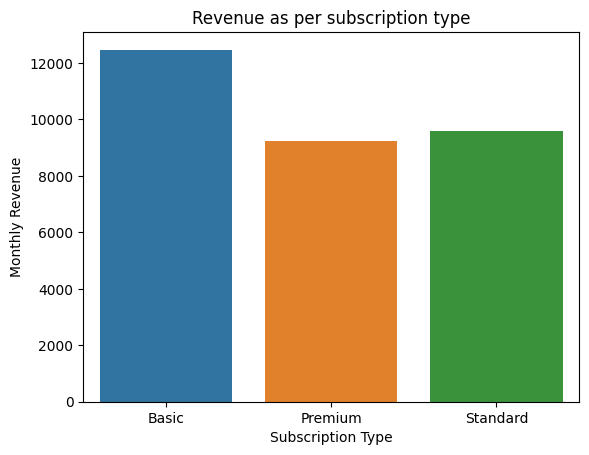

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.barplot(x=df_rev_sub['Subscription Type'],y= df_rev_sub['Monthly Revenue'])
plt.title("Revenue as per subscription type")

Revenue by country

In [9]:
df_rev_country=df.groupby(by='Country')['Monthly Revenue'].sum().reset_index()
df_rev_country

,Country,Monthly Revenue
0,Australia,2271
1,Brazil,2285
2,Canada,3950
3,France,2307
4,Germany,2260
5,Italy,2317
6,Mexico,2237
7,Spain,5662
8,United Kingdom,2318
9,United States,5664


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Australia'),
  Text(1, 0, 'Brazil'),
  Text(2, 0, 'Canada'),
  Text(3, 0, 'France'),
  Text(4, 0, 'Germany'),
  Text(5, 0, 'Italy'),
  Text(6, 0, 'Mexico'),
  Text(7, 0, 'Spain'),
  Text(8, 0, 'United Kingdom'),
  Text(9, 0, 'United States')])

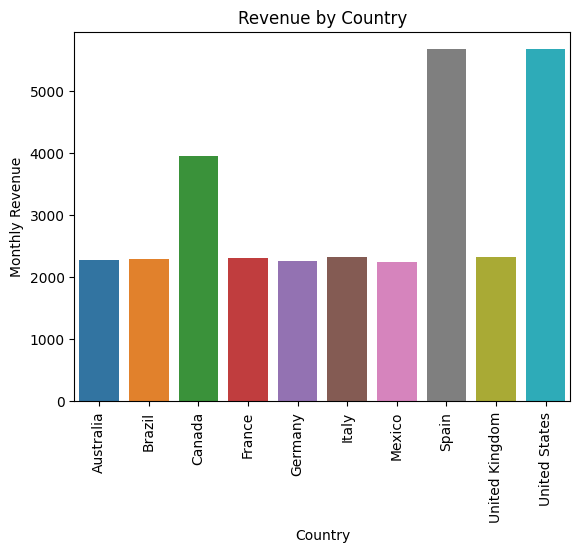

In [10]:
sns.barplot(x=df_rev_country['Country'],y= df_rev_country['Monthly Revenue'])
plt.title("Revenue by Country")
plt.xticks(rotation=90)

# Subscription Trends

Calculating the growth rate.

In [11]:
df['Join Date'] = pd.to_datetime(df['Join Date'])
df_growth = df.resample('M', on='Join Date')['User ID'].count()
df_growth.rename("New Users", inplace=True)

<ipython-input-11-3e326b1ecafd>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Join Date'] = pd.to_datetime(df['Join Date'])
<ipython-input-11-3e326b1ecafd>:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_growth = df.resample('M', on='Join Date')['User ID'].count()


Join Date
2021-05-31      3
2021-06-30      0
2021-07-31      0
2021-08-31      1
2021-09-30      4
2021-10-31      2
2021-11-30      2
2021-12-31      2
2022-01-31     81
2022-02-28     87
2022-03-31     97
2022-04-30    106
2022-05-31    129
2022-06-30    336
2022-07-31    393
2022-08-31    291
2022-09-30    301
2022-10-31    415
2022-11-30    117
2022-12-31     95
2023-01-31      7
2023-02-28      5
2023-03-31      6
2023-04-30      2
2023-05-31      3
2023-06-30      2
2023-07-31      3
2023-08-31      4
2023-09-30      1
2023-10-31      1
2023-11-30      3
2023-12-31      1
Freq: ME, Name: New Users, dtype: int64

In [12]:

df_growth_rate = df_growth.pct_change() * 100
df_growth_rate

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


Join Date
2021-05-31            NaN
2021-06-30    -100.000000
2021-07-31            NaN
2021-08-31            inf
2021-09-30     300.000000
2021-10-31     -50.000000
2021-11-30       0.000000
2021-12-31       0.000000
2022-01-31    3950.000000
2022-02-28       7.407407
2022-03-31      11.494253
2022-04-30       9.278351
2022-05-31      21.698113
2022-06-30     160.465116
2022-07-31      16.964286
2022-08-31     -25.954198
2022-09-30       3.436426
2022-10-31      37.873754
2022-11-30     -71.807229
2022-12-31     -18.803419
2023-01-31     -92.631579
2023-02-28     -28.571429
2023-03-31      20.000000
2023-04-30     -66.666667
2023-05-31      50.000000
2023-06-30     -33.333333
2023-07-31      50.000000
2023-08-31      33.333333
2023-09-30     -75.000000
2023-10-31       0.000000
2023-11-30     200.000000
2023-12-31     -66.666667
Freq: ME, Name: New Users, dtype: float64

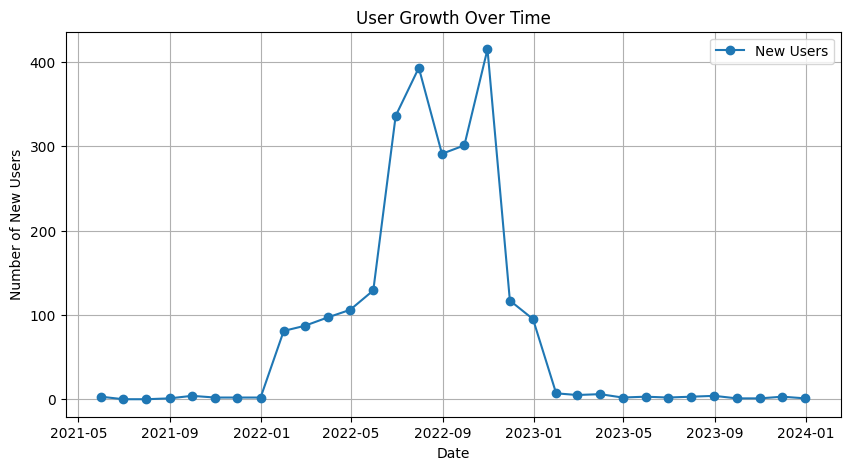

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_growth.index, df_growth, marker='o', linestyle='-', label='New Users')
plt.xlabel('Date')
plt.ylabel('Number of New Users')
plt.title('User Growth Over Time')
plt.legend()
plt.grid()
plt.show()

As you can see the two spikes are in the holiday season.

Determining the plan popularity.

In [14]:
df_plan_pop=df.groupby(by='Subscription Type')['User ID'].count().reset_index()
df_plan_pop

,Subscription Type,User ID
0,Basic,999
1,Premium,733
2,Standard,768


Text(0.5, 1.0, 'Plan popularity as per User Base')

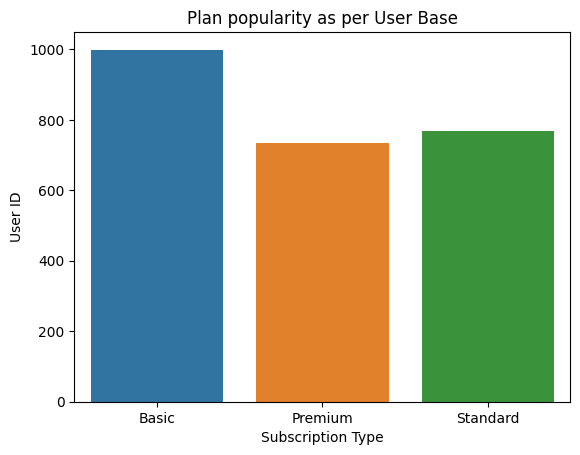

In [15]:
sns.barplot(x=df_plan_pop['Subscription Type'],y= df_plan_pop['User ID'])
plt.title("Plan popularity as per User Base")

Demographic Insights.

Gender based Analysis

In [16]:
df_gen=df['Gender'].value_counts().reset_index()
df_gen

,Gender,count
0,Female,1257
1,Male,1243


Text(0.5, 1.0, 'Gender Distribution')

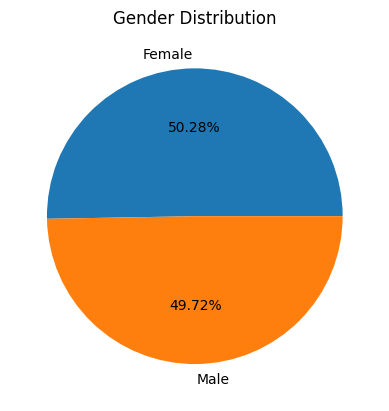

In [17]:
plt.pie(df_gen['count'],labels=df_gen['Gender'],autopct='%1.2f%%')
plt.title("Gender Distribution")

In [18]:
df_gen_sub_plan = pd.pivot_table(df, 
                                 index='Gender', 
                                 columns='Subscription Type', 
                                 values='User ID',  # Use a unique identifier
                                 aggfunc='count').reset_index()

df_gen_sub_plan

Subscription Type,Gender,Basic,Premium,Standard
0,Female,512,364,381
1,Male,487,369,387


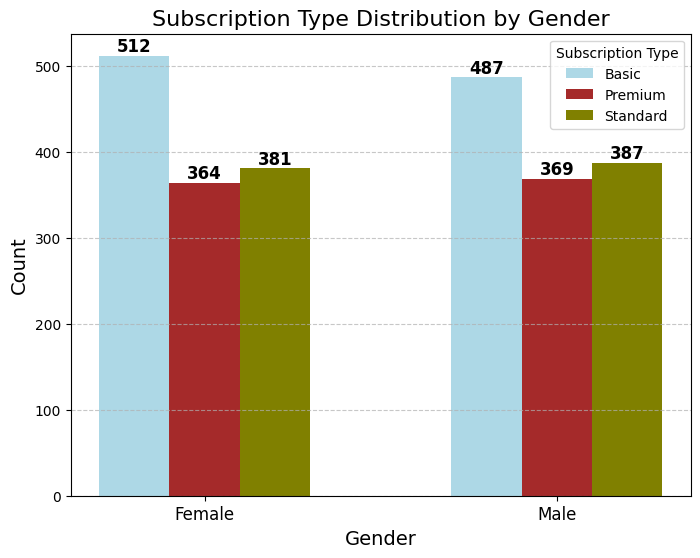

In [19]:
plt.figure(figsize=(8, 6))

# Define bar width and positions
bar_width = 0.2
x = np.arange(len(df_gen_sub_plan['Gender']))  # X-axis positions

# Create bars for each category
bars1 = plt.bar(x - bar_width, df_gen_sub_plan['Basic'], width=bar_width, label='Basic', color='lightblue')
bars2 = plt.bar(x, df_gen_sub_plan['Premium'], width=bar_width, label='Premium', color='brown')
bars3 = plt.bar(x + bar_width, df_gen_sub_plan['Standard'], width=bar_width, label='Standard', color='olive')

# Add annotations
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 f'{bar.get_height()}', ha='center', fontsize=12, fontweight='bold')

# Customizing the plot
plt.xlabel("Gender", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Subscription Type Distribution by Gender", fontsize=16)
plt.xticks(x, df_gen_sub_plan['Gender'], fontsize=12)
plt.legend(title="Subscription Type")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()

Country Based Analysis.

In [20]:
df_coun_sub_plan=pd.pivot_table(df,index='Subscription Type',columns='Country',aggfunc=['count'],values='User ID').reset_index()
df_coun_sub_plan

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


Subscription Type     count                                      \
Country                   Australia Brazil Canada France Germany  Italy   
0                   Basic      31.0  146.0  145.0   36.0   149.0  176.0   
1                 Premium     101.0   33.0   88.0  147.0     3.0    4.0   
2                Standard      51.0    4.0   84.0    NaN    31.0    3.0   

                                                    
Country Mexico  Spain United Kingdom United States  
0          4.0  110.0            3.0         199.0  
1          NaN  212.0            NaN         145.0  
2        179.0  129.0          180.0         107.0

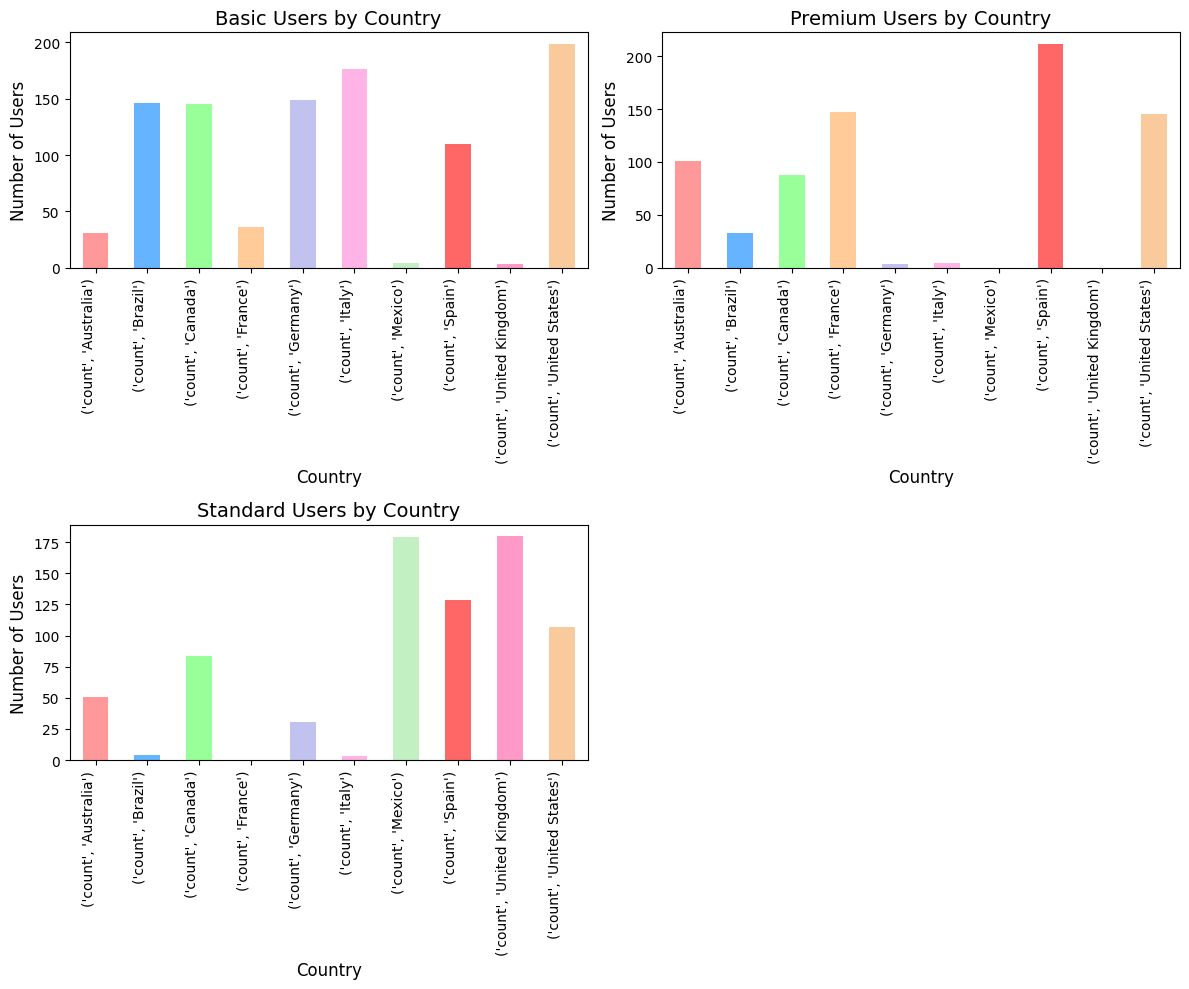

In [25]:
# Fill NaN values with 0 for better visualization
df_coun_sub_plan = df_coun_sub_plan.fillna(0)

# Set figure size and layout (2 rows, 2 columns)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))  # Bigger figure size

# Subscription types
subscription_types = df_coun_sub_plan['Subscription Type']

# Flatten axes for easy iteration
axes = axes.flatten()

# Iterate through each subscription type and create a subplot
for i, sub_type in enumerate(subscription_types):
    ax = axes[i]
    df_coun_sub_plan.iloc[i, 1:].plot(kind='bar', ax=ax, color=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6','#c2f0c2','#ff6666','#ff99c8','#f9cb9c'])
    
    ax.set_title(f"{sub_type} Users by Country", fontsize=14)
    ax.set_xlabel("Country", fontsize=12)
    ax.set_ylabel("Number of Users", fontsize=12)
    ax.set_xticklabels(df_coun_sub_plan.columns[1:], rotation=90, ha="right", fontsize=10)

# Remove any unused subplot if we have extra space
if len(subscription_types) < len(axes):
    for j in range(len(subscription_types), len(axes)):
        fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()


1. The United States has the highest number of users subscribed to the Basic plan.
2. Spain has the largest user base for the Premium plan.
3. The United Kingdom has the highest number of Standard plan subscribers.

Age based analysis

As the values are continuous, we divide the age into different groups

In [26]:
bins = [0, 18, 25, 35, 45, 60, 100]  # Define age group ranges
labels = ['0-18', '19-25', '26-35', '36-45', '46-60', '60+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

Printing the various age groups along with the number of entries in the dataset

In [28]:
age_group_counts = df['Age Group'].value_counts().sort_index()
age_group_counts

Age Group
0-18       0
19-25      0
26-35    916
36-45    999
46-60    585
60+        0
Name: count, dtype: int64

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


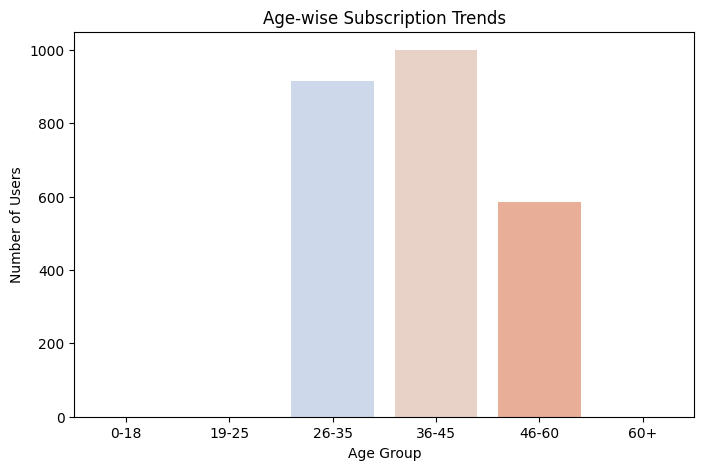

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, palette='coolwarm')
plt.xlabel('Age Group')
plt.ylabel('Number of Users')
plt.title('Age-wise Subscription Trends')
plt.show()

As you can see the highest number of users fall in the age-group of 36-45

<ipython-input-30-4aab70b9ca0a>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_subscription = df.groupby(['Age Group', 'Subscription Type']).size().unstack()


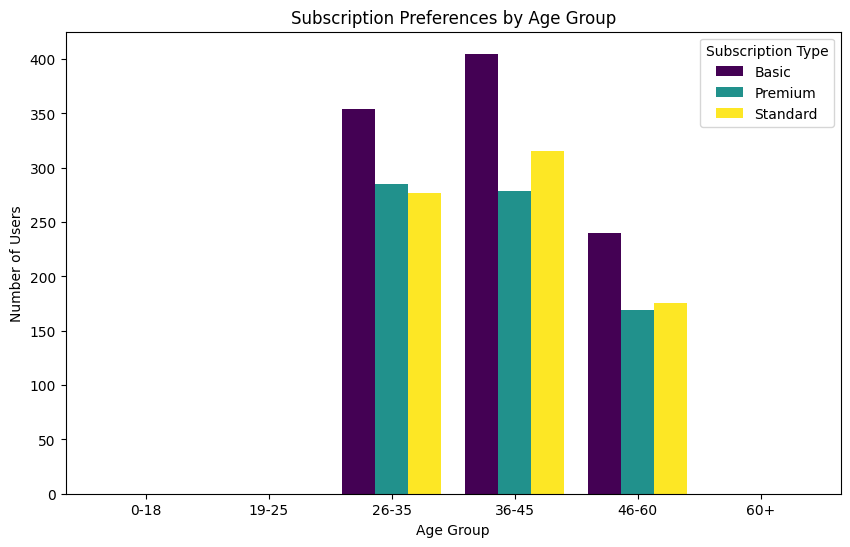

In [30]:
age_subscription = df.groupby(['Age Group', 'Subscription Type']).size().unstack()
age_subscription.plot(kind='bar', figsize=(10,6), colormap='viridis', width=0.8)
plt.xlabel('Age Group')
plt.ylabel('Number of Users')
plt.title('Subscription Preferences by Age Group')
plt.legend(title='Subscription Type')
plt.xticks(rotation=0)
plt.show()

# Device Usage Patterns

In [31]:
df_device_usage=df['Device'].value_counts().reset_index()
df_device_usage

,Device,count
0,Laptop,636
1,Tablet,633
2,Smartphone,621
3,Smart TV,610


Text(0.5, 1.0, 'Device usage Pattern')

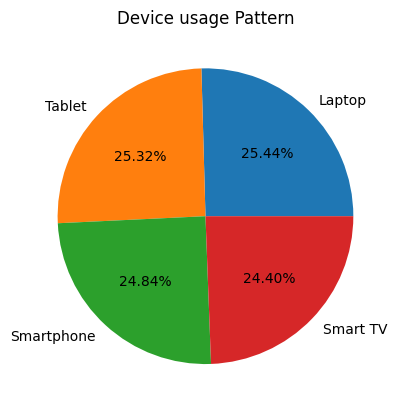

In [35]:
plt.pie(df_device_usage['count'],labels=df_device_usage['Device'],autopct='%1.2f%%')
plt.title("Device usage Pattern")

Revenue by device

In [36]:
df_rev_dev=df.groupby(by='Device')['Monthly Revenue'].sum().reset_index()
df_rev_dev

,Device,Monthly Revenue
0,Laptop,7994
1,Smart TV,7615
2,Smartphone,7691
3,Tablet,7971


Text(0.5, 1.0, 'Revenue share by device category')

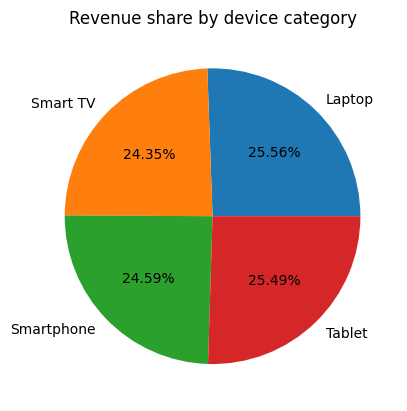

In [39]:
plt.pie(df_rev_dev['Monthly Revenue'], labels=df_rev_dev['Device'],autopct='%1.2f%%')
plt.title("Revenue share by device category")

As you can see the device usage among smart TV, smartPhone, tablet and Laptop is almost unifrom and the revenue contribution is also uniform.

# Pricing Strategy.

In [41]:
df_plan_rev=df.groupby(by='Subscription Type')['Monthly Revenue'].sum().reset_index()
df_plan_rev

,Subscription Type,Monthly Revenue
0,Basic,12469
1,Premium,9229
2,Standard,9573


**Conclution:**

1.  The distribution male and female users is almost the same.
2.  Also basic plan contributes most to the revenue, while standard bagging the second position and premium the last.
3.  There are four types of devices used by the users:    Laptop	    Smart TV	    Smartphone		Tablet
4.  All the four devices contribute almost the same in the revenue.
5.  People falling in the age group of 36-45 contribute to most number of       subscribers therebyc contributing to the most of the revenue.
6.  Also most of the customer acquision happens during vacations. ( Summer      vacations and Christmas break)
7.  The United States has the highest number of users subscribed to the         Basic plan.
8.  Spain has the largest user base for the Premium plan.
9.  The United Kingdom has the highest number of Standard plan subscribers.
